# Get Dataset

In [1]:
# import yfinance as yf
import pandas as pd
# from google.colab import files

stock_symbol = 'MAYA.JK'
start_date = '2023-12-18'
end_date = '2024-12-18'

# data = yf.download(stock_symbol, start=start_date, end=end_date)

# data.to_csv('maya_stock_data.csv')
# files.download('maya_stock_data.csv')

# Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('maya_stock_data.csv')
df.head()

,Price;Adj Close;Close;High;Low;Open;Volume
0,Ticker;MAYA.JK;MAYA.JK;MAYA.JK;MAYA.JK;MAYA.JK...
1,Date;;;;;;
2,18/12/2023;22.852.760.314.941.400;22.852.760.3...
3,19/12/2023;22.852.760.314.941.400;22.852.760.3...
4,20/12/2023;22.740.185.546.875;22.740.185.546.8...


# Preprocessing Data

In [3]:
df = df.iloc[2:]  # Mulai dari baris ke-3 (indeks ke-2)

# Ganti nama kolom 'Price' menjadi 'Date'
df = df.rename(columns={'Price': 'Date'})

# Ubah tipe data menjadi float untuk kolom angka
cols_to_convert = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Jika ingin membulatkan angka ke 2 desimal
df[['Adj Close', 'Close', 'High', 'Low', 'Open']] = df[['Adj Close', 'Close', 'High', 'Low', 'Open']].round(2)
df

KeyError: 'Adj Close'

In [43]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,238.000000,238.000000,238.000000,238.000000,238.000000,2.380000e+02
mean,257.945252,257.945252,266.924916,250.522689,258.650630,3.051887e+07
std,50.481345,50.481345,53.455374,48.442709,51.854093,5.518049e+07
min,158.000000,158.000000,165.000000,149.000000,158.000000,1.332440e+05
25%,222.500000,222.500000,226.000000,218.000000,222.000000,3.268950e+06
50%,245.000000,245.000000,254.000000,236.000000,244.000000,8.305300e+06
75%,292.000000,292.000000,300.000000,286.000000,293.500000,3.165745e+07
max,368.000000,368.000000,408.000000,354.000000,408.000000,4.047967e+08


# Visualisasi Harga Saham Awal

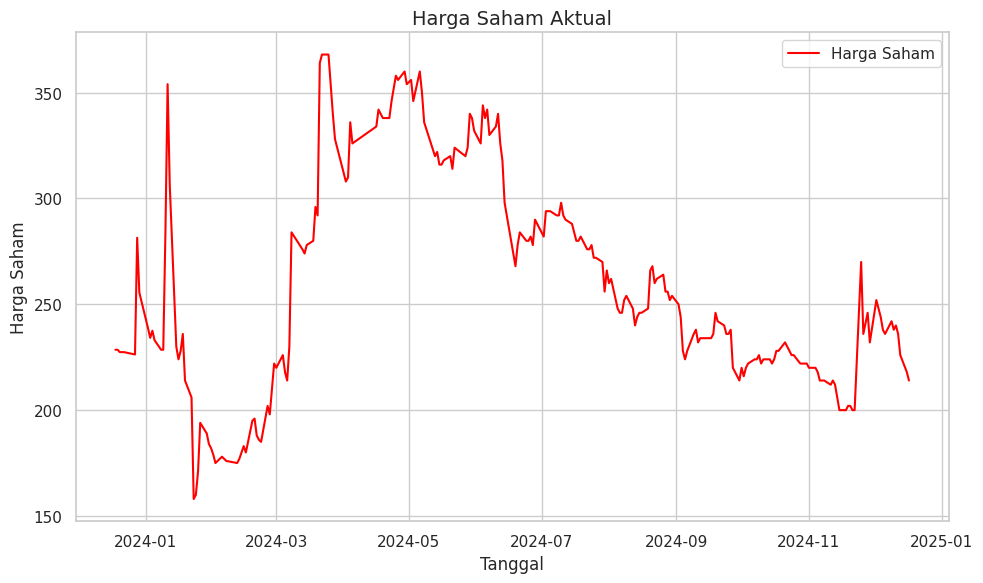

In [44]:
# Pastikan kolom 'Date' dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Plot data harga saham
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Close'], color='red', label='Harga Saham')

# Tambahkan detail plot
plt.title('Harga Saham Aktual', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Saham', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

# Tampilkan plot
plt.show()

# Penetapan kolom yang digunakan [Close]

In [45]:
stock_prices = df['Close']

# Return

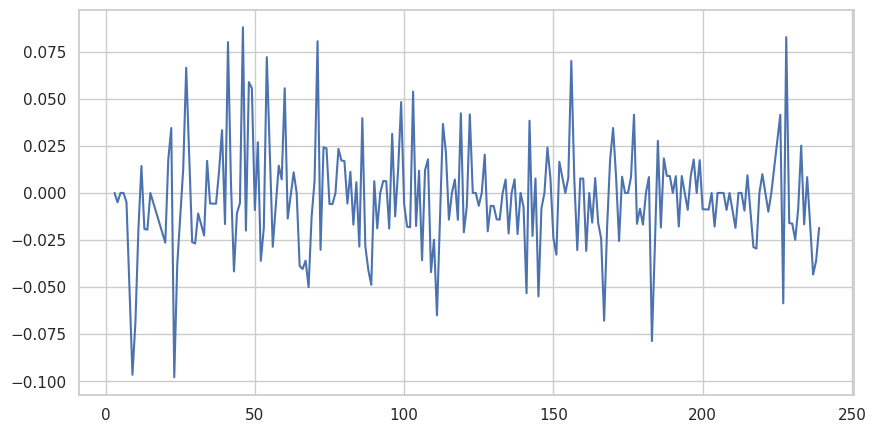

In [46]:
log_returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
log_returns = log_returns[(log_returns > -0.1) & (log_returns < 0.1)] # umumnya -10%-10%

# Plot hasilnya
log_returns.plot(figsize=(10, 5))
plt.show()

# Cek distribusi data

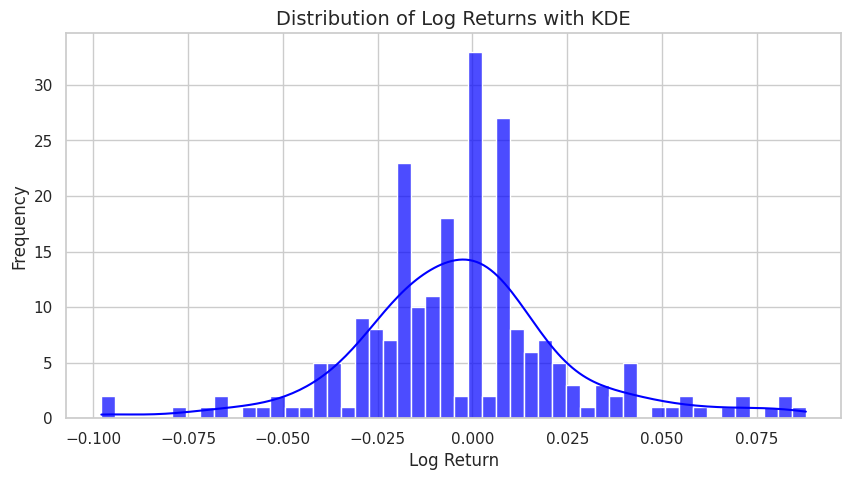

In [47]:
import seaborn as sns
plt.figure(figsize=(10, 5))

# Use Seaborn's kdeplot to check the distribution
sns.histplot(log_returns, bins=50, kde=True, color='blue', alpha=0.7)

# Add title and labels
plt.title('Distribution of Log Returns with KDE', fontsize=14)
plt.xlabel('Log Return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add grid for better readability
plt.grid(True)

# Show the plot
plt.show()

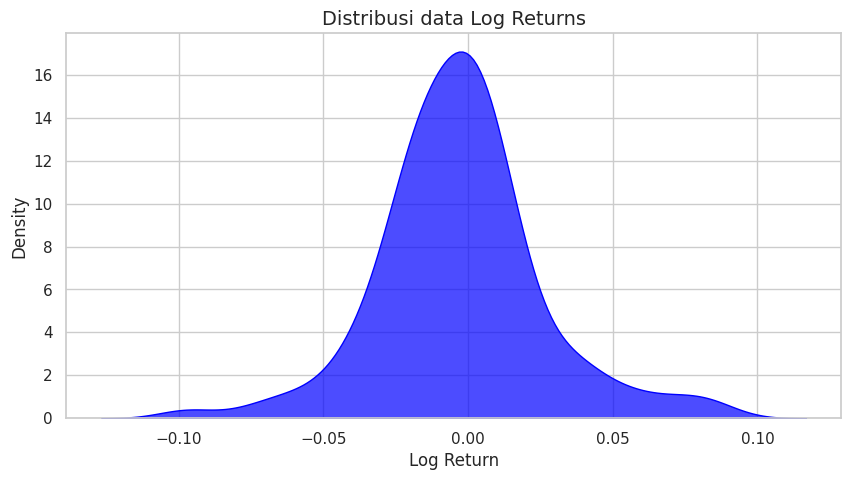

In [48]:
plt.figure(figsize=(10, 5))

# Plot the KDE
sns.kdeplot(log_returns, fill=True, color='blue', alpha=0.7)

# Add title and labels
plt.title('Distribusi data Log Returns', fontsize=14)
plt.xlabel('Log Return', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add grid for better readability
plt.grid(True)

# Show the plot
plt.show()

## Statistik Return

In [49]:
# Menghitung statistik dasar
mean_return = log_returns.mean()
std_return = log_returns.std()

print(f"Mean Return: {mean_return}")
print(f"Standard Deviation: {std_return}")

Mean Return: -0.002852736881347496
Standard Deviation: 0.028368347493724258


# Volatilitas

In [50]:
# volalitity adalah mengukur risiko fluktuasi pergerakan saham
volatility = log_returns.std()
print(f"Volatility: {volatility}")

Volatility: 0.028368347493724258


## Visualisasi Volatilitas

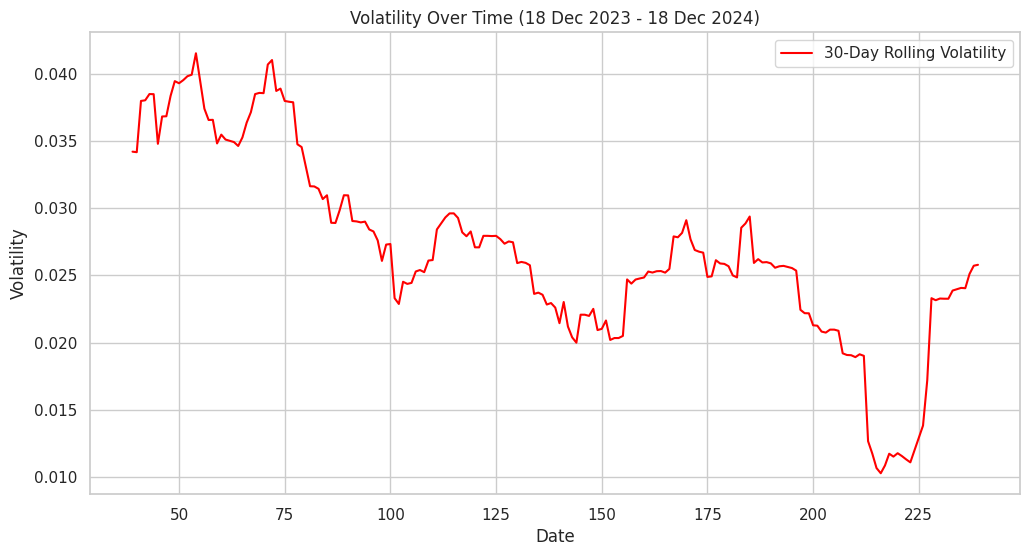

In [51]:
import matplotlib.pyplot as plt

# Misalkan 'log_returns' adalah return yang sudah dihitung sebelumnya
rolling_volatility = log_returns.rolling(window=30).std()  # Menggunakan window 30 hari

plt.figure(figsize=(12, 6))
plt.plot(rolling_volatility, label="30-Day Rolling Volatility", color='red')
plt.title("Volatility Over Time (18 Dec 2023 - 18 Dec 2024)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

# GBM dan monte carlo

In [52]:
s0 = df['Close'].iloc[-1]
R = 0.05               # Return harapan 5% karena moderat dan sering digunakan(tidak besar dan tidak kecil)
vol = volatility        # Gunakan volatilitas langsung
T = 1                   # Periode satu tahun

n_time_intervals = 21 #238 data asli
N_sim = 10000000 # sebanyak 10.000 simulasi pergerakan harga saham
# semakin banyak jumlah pergerakan, semakin membuat realistis dan mengurangi ketidakpastian

# menghitung ukuran waktu per interval
delta_t = T / n_time_intervals

# Inisialisasi S_fwd dengan ukuran yang benar
S_fwd = np.zeros((n_time_intervals + 1, N_sim))
S_fwd[0] = s0  # Set nilai awal

# Simulasi pergerakan harga menggunakan Geometric Brownian Motion
for t in range(1, n_time_intervals + 1):
    S_fwd[t] = S_fwd[t - 1] * np.exp((R - 0.5 * vol**2) * delta_t + vol * np.sqrt(delta_t) * np.random.standard_normal(N_sim))

# Perhitungan perubahan harga rata-rata
# perubahan harga saham rata-rata yang diproyeksikan dibandingkan dengan harga awal (s0)
delta_stock_price = (S_fwd[-1] - s0).mean() / s0
delta_stock_price_percentage = '{:.2%}'.format(delta_stock_price)
print('Stock price forecast:', delta_stock_price_percentage)

Stock price forecast: 5.13%


## Visualisasi Stock Prices

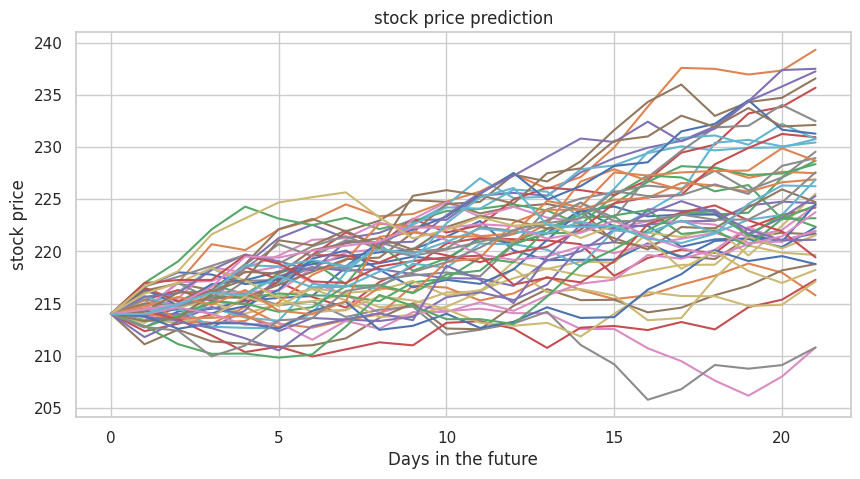

In [53]:
plt.figure(figsize=(10,5))
plt.plot(S_fwd[:,0:50]) # 50 jalur simulasi pertama
plt.xlabel('Days in the future')
plt.ylabel('stock price')
plt.title('stock price prediction')
plt.show()

## Statistik Stock Prices

In [54]:
final_prices = S_fwd[-1, :]
print(f"Min final price: {final_prices.min()}")
print(f"Max final price: {final_prices.max()}")
print(f"Mean final price: {final_prices.mean()}")

Min final price: 194.78341583517653
Max final price: 263.6626164536497
Mean final price: 224.9683859188066


# Visualisasi ALL

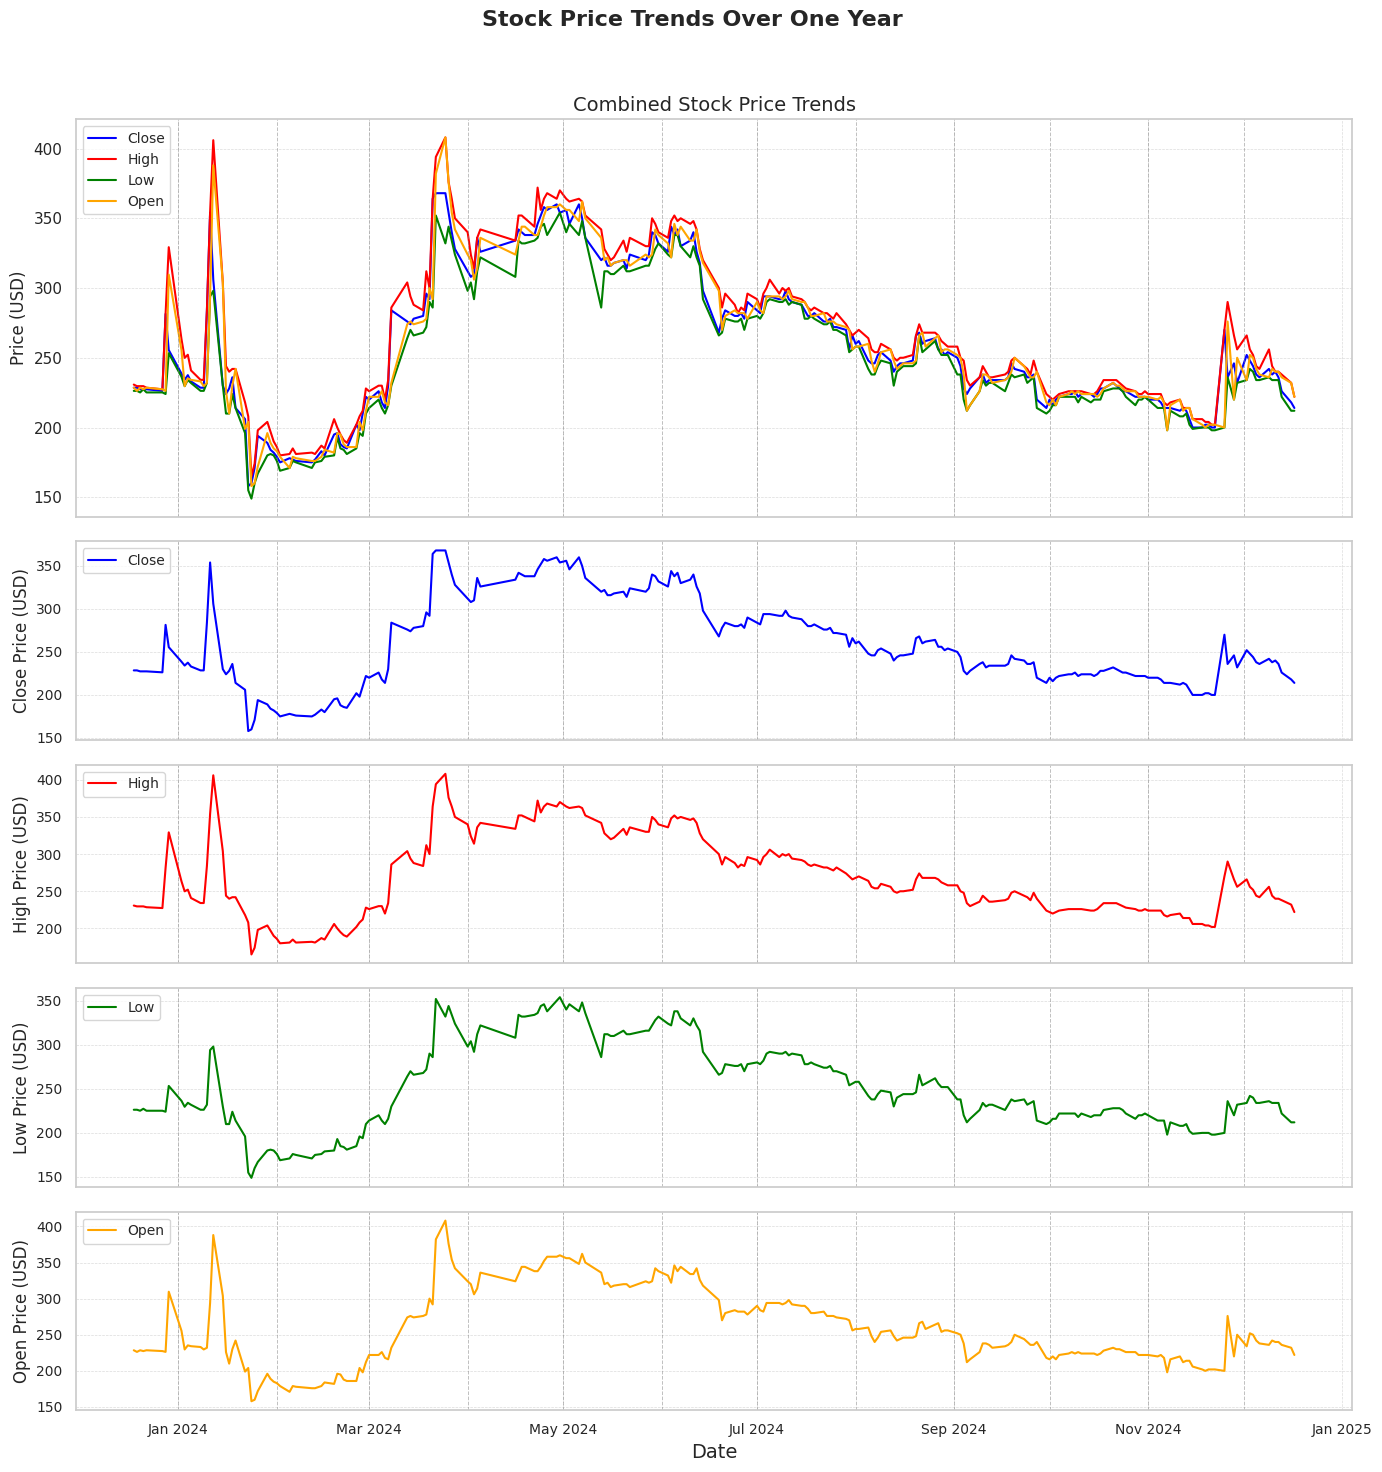

In [55]:
from matplotlib.dates import DateFormatter, MonthLocator
# Set seaborn style untuk visualisasi yang lebih baik
sns.set(style="whitegrid")

# 1. Visualisasi Tren Harga Aktual
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1, 1, 1]})
price_types = ['Close', 'High', 'Low', 'Open']
colors = ['blue', 'red', 'green', 'orange']

month_locator = MonthLocator()
date_formatter = DateFormatter('%b %Y')

# Plot gabungan
for price_type, color in zip(price_types, colors):
    axes[0].plot(df['Date'], df[price_type], label=price_type, color=color, linewidth=1.5)
axes[0].set_title('Combined Stock Price Trends', fontsize=14)
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(visible=True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Tambahkan garis vertikal untuk setiap bulan
for ax in axes:
    for date in month_locator.tick_values(df['Date'].min(), df['Date'].max()):
        ax.axvline(x=date, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

# Subplot individual
for i, price_type in enumerate(price_types):
    axes[i + 1].plot(df['Date'], df[price_type], label=price_type, color=colors[i], linewidth=1.5)
    axes[i + 1].set_ylabel(f'{price_type} Price (USD)', fontsize=12)
    axes[i + 1].legend(loc='upper left', fontsize=10)
    axes[i + 1].grid(visible=True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    axes[i + 1].tick_params(axis='y', labelsize=10)

# Format x-axis pada subplot terakhir
axes[-1].set_xlabel('Date', fontsize=14)
axes[-1].xaxis.set_major_formatter(date_formatter)
plt.xticks(fontsize=10)

# Tambahkan judul keseluruhan
fig.suptitle('Stock Price Trends Over One Year', fontsize=16, weight='bold')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

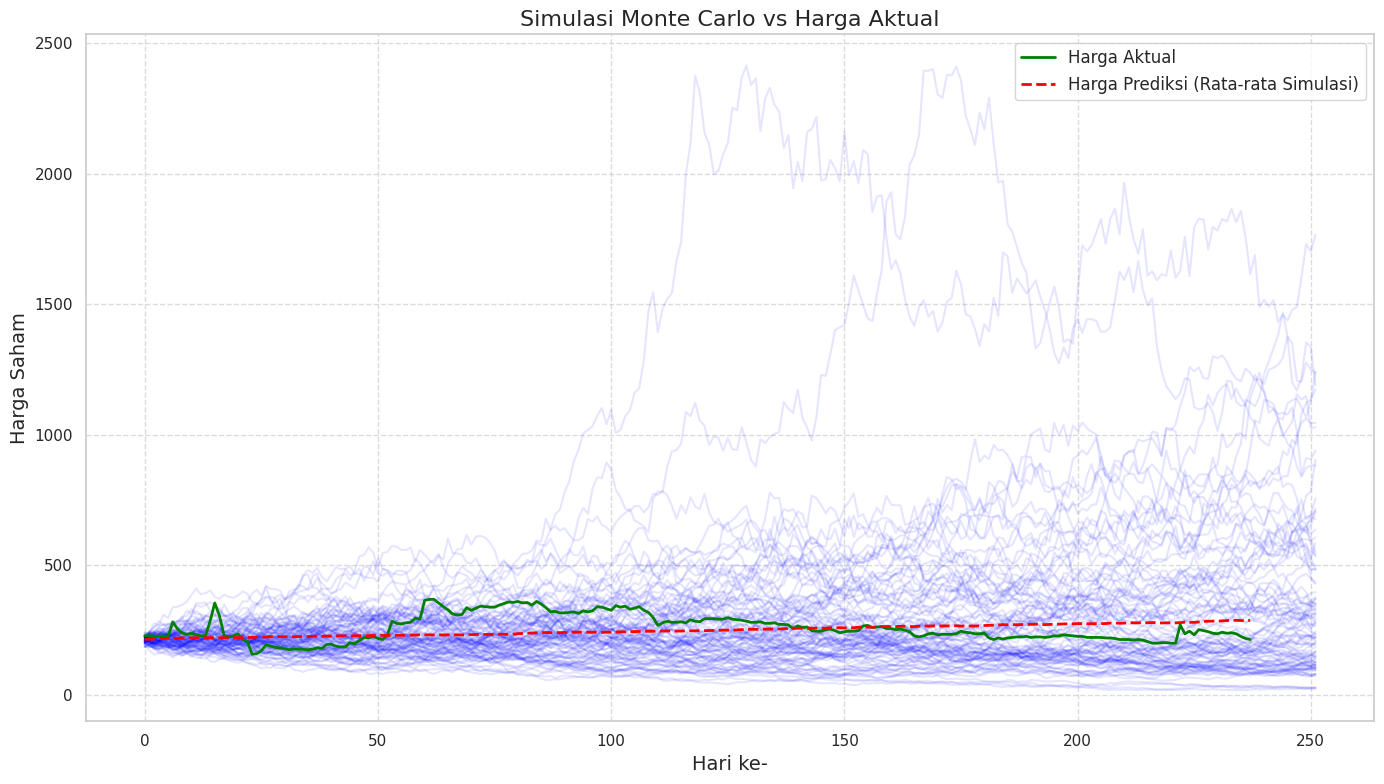

In [56]:
# 2. Simulasi Monte Carlo
def monte_carlo_simulation(data, num_simulations=1000, num_days=252):
    # Hitung log-return
    data['LogReturn'] = np.log(data['Close'] / data['Close'].shift(1))
    data = data.dropna()

    mean_return = data['LogReturn'].mean()
    std_dev_return = data['LogReturn'].std()

    last_price = data['Close'].iloc[-1]
    simulations = np.zeros((num_days, num_simulations))

    for i in range(num_simulations):
        daily_returns = np.random.normal(mean_return, std_dev_return, num_days)
        price_path = last_price * np.exp(np.cumsum(daily_returns))
        simulations[:, i] = price_path

    return simulations

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Simulasi Monte Carlo
simulated_prices = monte_carlo_simulation(df, num_simulations=1000, num_days=252)
mean_simulated_prices = simulated_prices.mean(axis=1)

# Aktual vs Prediksi
actual_prices = df['Close'][-252:].values
predicted_prices = mean_simulated_prices[:len(actual_prices)]

# Visualisasi hasil simulasi dan perbandingan aktual vs prediksi
plt.figure(figsize=(14, 8))
for i in range(100):
    plt.plot(simulated_prices[:, i], alpha=0.1, color='blue')
plt.plot(range(len(actual_prices)), actual_prices, label='Harga Aktual', color='green', linewidth=2)
plt.plot(range(len(predicted_prices)), predicted_prices, label='Harga Prediksi (Rata-rata Simulasi)', color='red', linestyle='--', linewidth=2)

plt.title('Simulasi Monte Carlo vs Harga Aktual', fontsize=16)
plt.xlabel('Hari ke-', fontsize=14)
plt.ylabel('Harga Saham', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

    Actual   Predicted        APE    Return  Volatility
0    200.0  214.509758   7.254879       NaN         NaN
1    202.0  215.021444   6.446260  0.010000         NaN
2    202.0  215.534149   6.700074  0.000000         NaN
3    200.0  216.047078   8.023539 -0.009901         NaN
4    200.0  216.561354   8.280677  0.000000         NaN
5    270.0  217.077289  19.601004  0.350000    0.156672
6    236.0  217.595085   7.798693 -0.125926    0.179779
7    246.0  218.114191  11.335695  0.042373    0.178247
8    232.0  218.633526   5.761411 -0.056911    0.183447
9    252.0  219.154518  13.033921  0.086207    0.182572
10   248.0  219.676607  11.420723 -0.015873    0.083054
11   244.0  220.200493   9.753896 -0.016129    0.056266
12   238.0  220.724867   7.258459 -0.024590    0.053940
13   236.0  221.251245   6.249472 -0.008403    0.046176
14   242.0  221.777801   8.356281  0.025424    0.019497
15   238.0  222.307290   6.593575 -0.016529    0.019566
16   240.0  222.837085   7.151215  0.008403    0

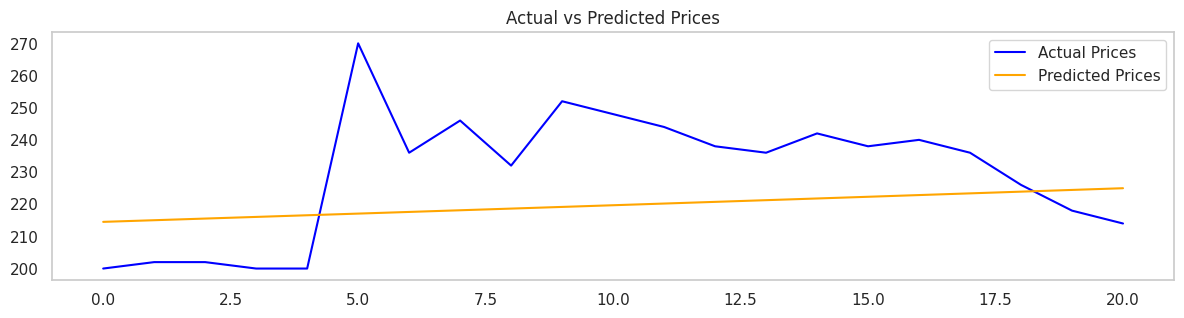

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mengambil harga aktual dari dataset asli (sesuai data historis)
actual_prices = df['Close'].iloc[-n_time_intervals:]  # Data harga saham aktual

# Menghitung rata-rata harga saham prediksi dari simulasi terakhir
predicted_prices = S_fwd.mean(axis=1)  # Rata-rata dari semua simulasi
predicted_prices = predicted_prices[-n_time_intervals:]  # Ambil data sesuai jumlah interval waktu

# Validasi panjang data
if len(actual_prices) != len(predicted_prices):
    print("Error: Panjang data aktual dan prediksi tidak sesuai.")
else:
    # Membuat DataFrame untuk analisis
    results = pd.DataFrame({
        'Actual': actual_prices.values,  # DataFrame column
        'Predicted': predicted_prices  # NumPy array
    })

    # Menghitung APE untuk setiap data
    results['APE'] = np.abs((results['Actual'] - results['Predicted']) / results['Actual']) * 100

    # Menghitung Return sederhana
    results['Return'] = results['Actual'].pct_change()

    # Menghitung Volatilitas (rolling standar deviasi dari Return dengan jendela 5 hari)
    results['Volatility'] = results['Return'].rolling(window=5).std()

    # Menghitung MAPE
    mape = results['APE'].mean()

    # Menampilkan hasil
    print(results)
    print(f"\nMAPE: {mape:.2f}%")

    # Visualisasi hasil
    plt.figure(figsize=(12, 6))

    # Plot harga aktual vs prediksi
    plt.subplot(2, 1, 1)
    plt.plot(results['Actual'], label='Actual Prices', color='blue')
    plt.plot(results['Predicted'], label='Predicted Prices', color='orange')
    plt.title('Actual vs Predicted Prices')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()